In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

In [3]:
# 1. Carregar os dados prontos
df_bruto = pd.read_csv('base_senado_pronta_mineracao.csv', delimiter=';')

# 2. Garantir tipos numéricos corretos
df_bruto['HORAS_EXTRAS'] = pd.to_numeric(df_bruto['HORAS_EXTRAS'], errors='coerce').fillna(0)
df_bruto['REM_LIQUIDA'] = pd.to_numeric(df_bruto['REM_LIQUIDA'], errors='coerce').fillna(0)
df_bruto['REMUN_BASICA'] = pd.to_numeric(df_bruto['REMUN_BASICA'], errors='coerce').fillna(0)

# 3. Agrupar dados por Departamento (Lotação) e por Mês
# Vamos extrair o tamanho do setor (count) e a estrutura salarial como preditores
df_painel = df_bruto.groupby(['LOTAÇÃO EXERCÍCIO', 'MES_REFERENCIA', 'ANO EXERCÍCIO']).agg(
    Qtd_Servidores=('REM_LIQUIDA', 'count'),
    Total_Remun_Basica=('REMUN_BASICA', 'sum'),
    Gasto_Total_HE=('HORAS_EXTRAS', 'sum')
).reset_index()

# 4. Transformar a Lotação (Texto) em variáveis numéricas (One-Hot Encoding)
# O Random Forest precisa de números para tomar decisões nas árvores
df_modelo = pd.get_dummies(df_painel, columns=['LOTAÇÃO EXERCÍCIO', 'MES_REFERENCIA'], drop_first=True)

print(f"Estrutura gerada para o modelo: {df_modelo.shape[0]} linhas (combinações de dep./mês) e {df_modelo.shape[1]} colunas.")
df_painel[['LOTAÇÃO EXERCÍCIO', 'MES_REFERENCIA', 'Qtd_Servidores', 'Gasto_Total_HE']].head()

Estrutura gerada para o modelo: 34380 linhas (combinações de dep./mês) e 793 colunas.


,LOTAÇÃO EXERCÍCIO,MES_REFERENCIA,Qtd_Servidores,Gasto_Total_HE
0,ADVOCACIA DO SENADO FEDERAL,1,4,0.0
1,ADVOCACIA DO SENADO FEDERAL,1,2,0.0
2,ADVOCACIA DO SENADO FEDERAL,2,3,0.0
3,ADVOCACIA DO SENADO FEDERAL,2,2,0.0
4,ADVOCACIA DO SENADO FEDERAL,3,4,0.0


In [4]:
# Definir nossa variável alvo (Y) e as variáveis preditoras (X)
Y = df_modelo['Gasto_Total_HE']
X = df_modelo.drop(columns=['Gasto_Total_HE', 'ANO EXERCÍCIO'])

# Dividir o banco de dados
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size=0.20, random_state=42)

print(f"Dados de Treino: {X_treino.shape[0]} registros")
print(f"Dados de Teste: {X_teste.shape[0]} registros")

Dados de Treino: 27504 registros
Dados de Teste: 6876 registros


In [5]:
# Inicializar o Regressor do Random Forest
# n_estimators=100 significa que usaremos 100 árvores de decisão combinadas
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Treinar o algoritmo com a base do Senado
modelo_rf.fit(X_treino, Y_treino)

print("Random Forest treinado com sucesso!")

Random Forest treinado com sucesso!


In [6]:
# Realizar as previsões na base de teste que o modelo nunca viu
previsoes = modelo_rf.predict(X_teste)

# Calcular métricas de erro
r2 = r2_score(Y_teste, previsoes)
mae = mean_absolute_error(Y_teste, previsoes)

print("=== DESEMPENHO DO RANDOM FOREST ===")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Erro Médio Absoluto (MAE): R$ {mae:.2f}")
print("-----------------------------------")
print("Interpretação: Em média, o modelo acerta as previsões de gastos dos departamentos com uma margem de erro de R$", round(mae, 2))

=== DESEMPENHO DO RANDOM FOREST ===
Coeficiente de Determinação (R²): 0.5090
Erro Médio Absoluto (MAE): R$ 344.71
-----------------------------------
Interpretação: Em média, o modelo acerta as previsões de gastos dos departamentos com uma margem de erro de R$ 344.71


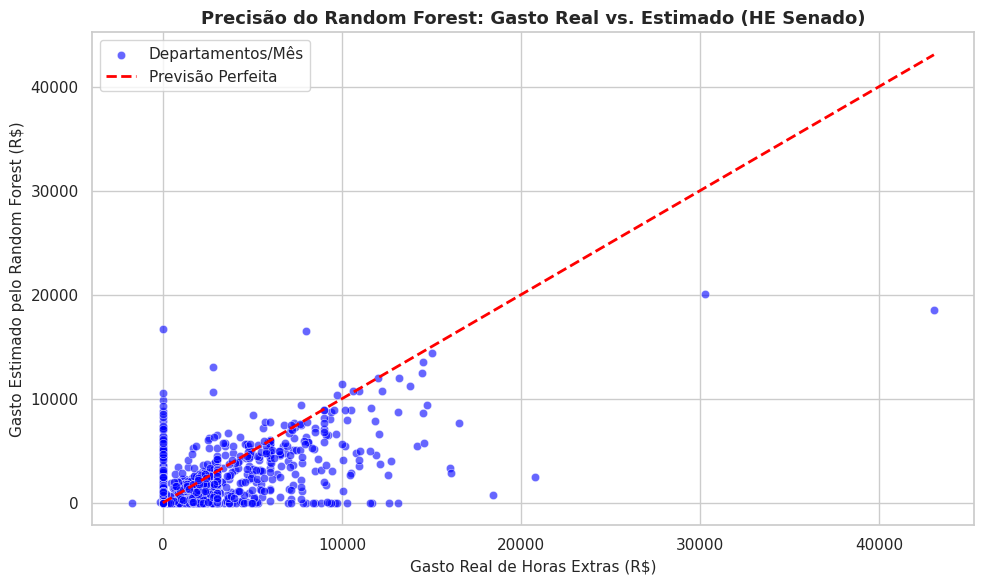

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y_teste, y=previsoes, alpha=0.6, color='blue', label='Departamentos/Mês')

# Linha ideal de perfeição (onde Previsão = Real)
limite = max(max(Y_teste), max(previsoes))
plt.plot([0, limite], [0, limite], color='red', linestyle='--', linewidth=2, label='Previsão Perfeita')

plt.title('Precisão do Random Forest: Gasto Real vs. Estimado (HE Senado)', fontsize=13, fontweight='bold')
plt.xlabel('Gasto Real de Horas Extras (R$)', fontsize=11)
plt.ylabel('Gasto Estimado pelo Random Forest (R$)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_499/3497482825.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_fatores, x='Importancia', y='Fator', palette='viridis')


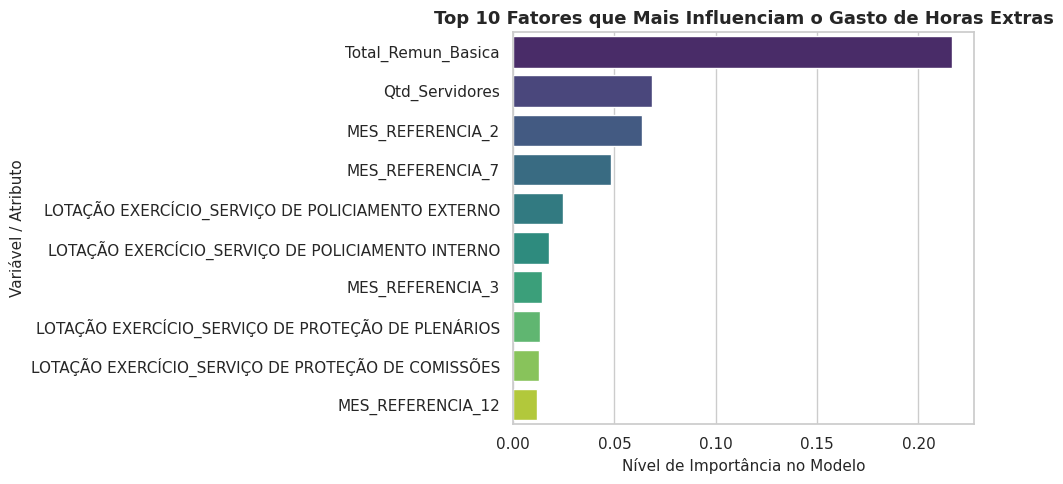

In [8]:
# Extrair a importância dos fatores calculada pelas árvores
importancias = modelo_rf.feature_importances_
df_importancia = pd.DataFrame({'Fator': X.columns, 'Importancia': importancias})

# Filtrar apenas os 10 fatores que mais influenciam o gasto
top_10_fatores = df_importancia.nlargest(10, 'Importancia')

plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_fatores, x='Importancia', y='Fator', palette='viridis')
plt.title('Top 10 Fatores que Mais Influenciam o Gasto de Horas Extras', fontsize=13, fontweight='bold')
plt.xlabel('Nível de Importância no Modelo', fontsize=11)
plt.ylabel('Variável / Atributo', fontsize=11)
plt.tight_layout()
plt.show()